# Quality control and doublets removal of the 78-sample AL cohort

**Biology rationale.** Reliable biological comparisons require removal of low-quality cells, ambient RNA, and doublets before integration and annotation.

**Aim.** Generate a quality-controlled, normalized, and integrated single-cell object for downstream analyses.

**Data input.** `240106-AL-all78.rds`, 

**Data outputs.** Processed objects, statistical summaries, and visualizations generated in the notebook.

## 1. Packages and setup


In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DoubletFinder)
library(SoupX)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
sce1<-readRDS('240106-AL-all78.rds')
sce1 <- JoinLayers(sce1)
sce1@active.assay<-'RNA'
sce1

An object of class Seurat 
36601 features across 777438 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing 

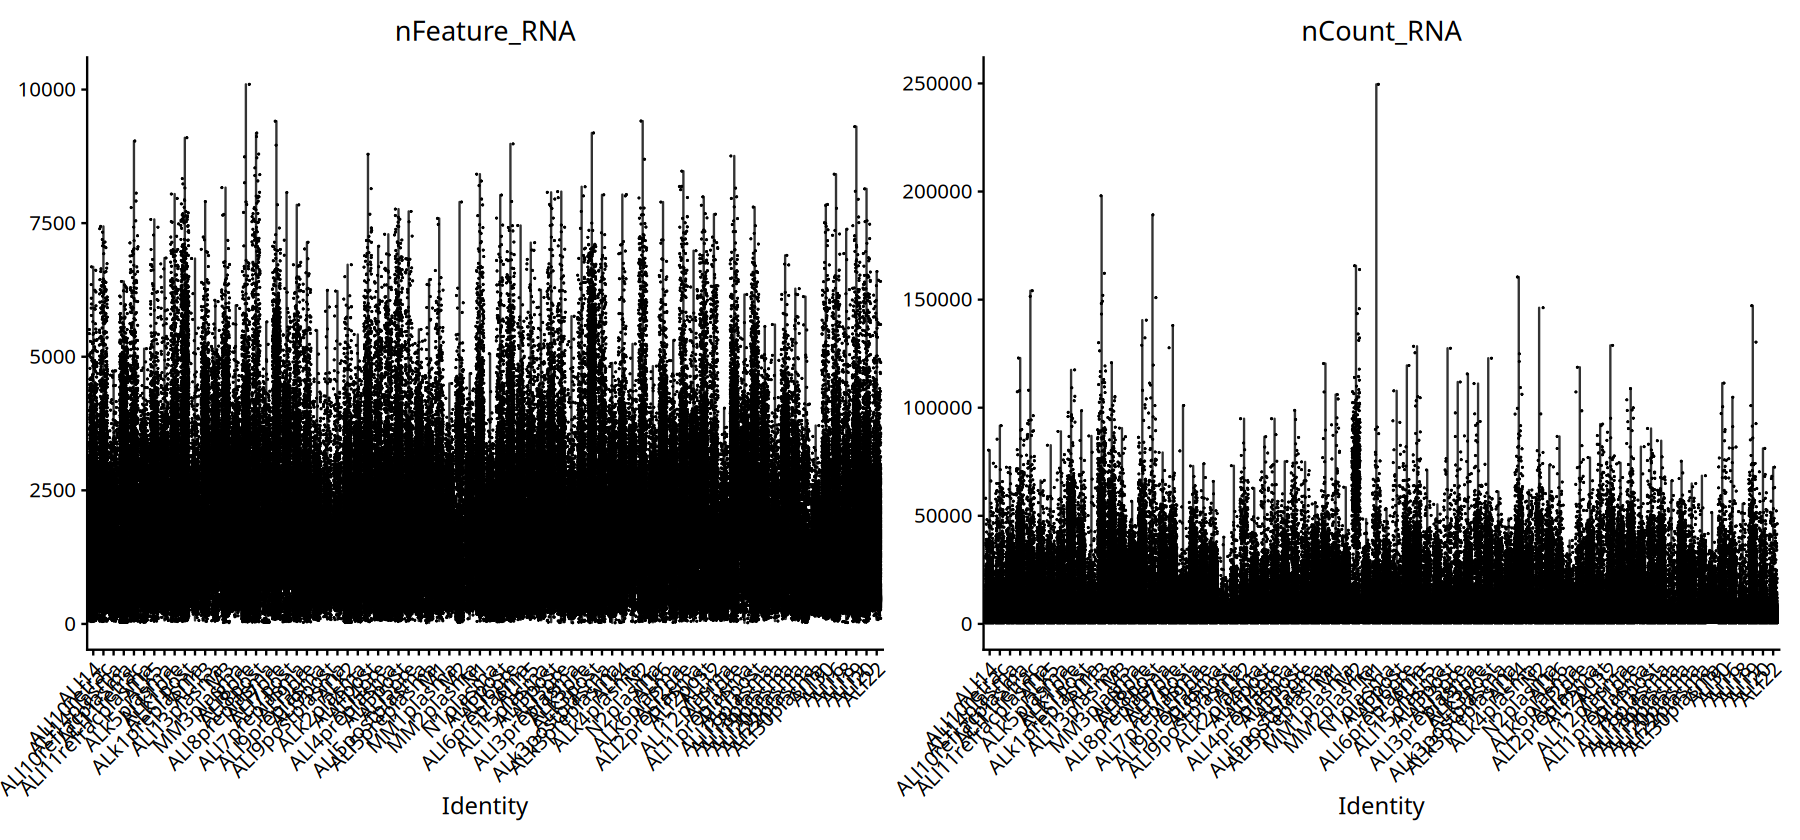

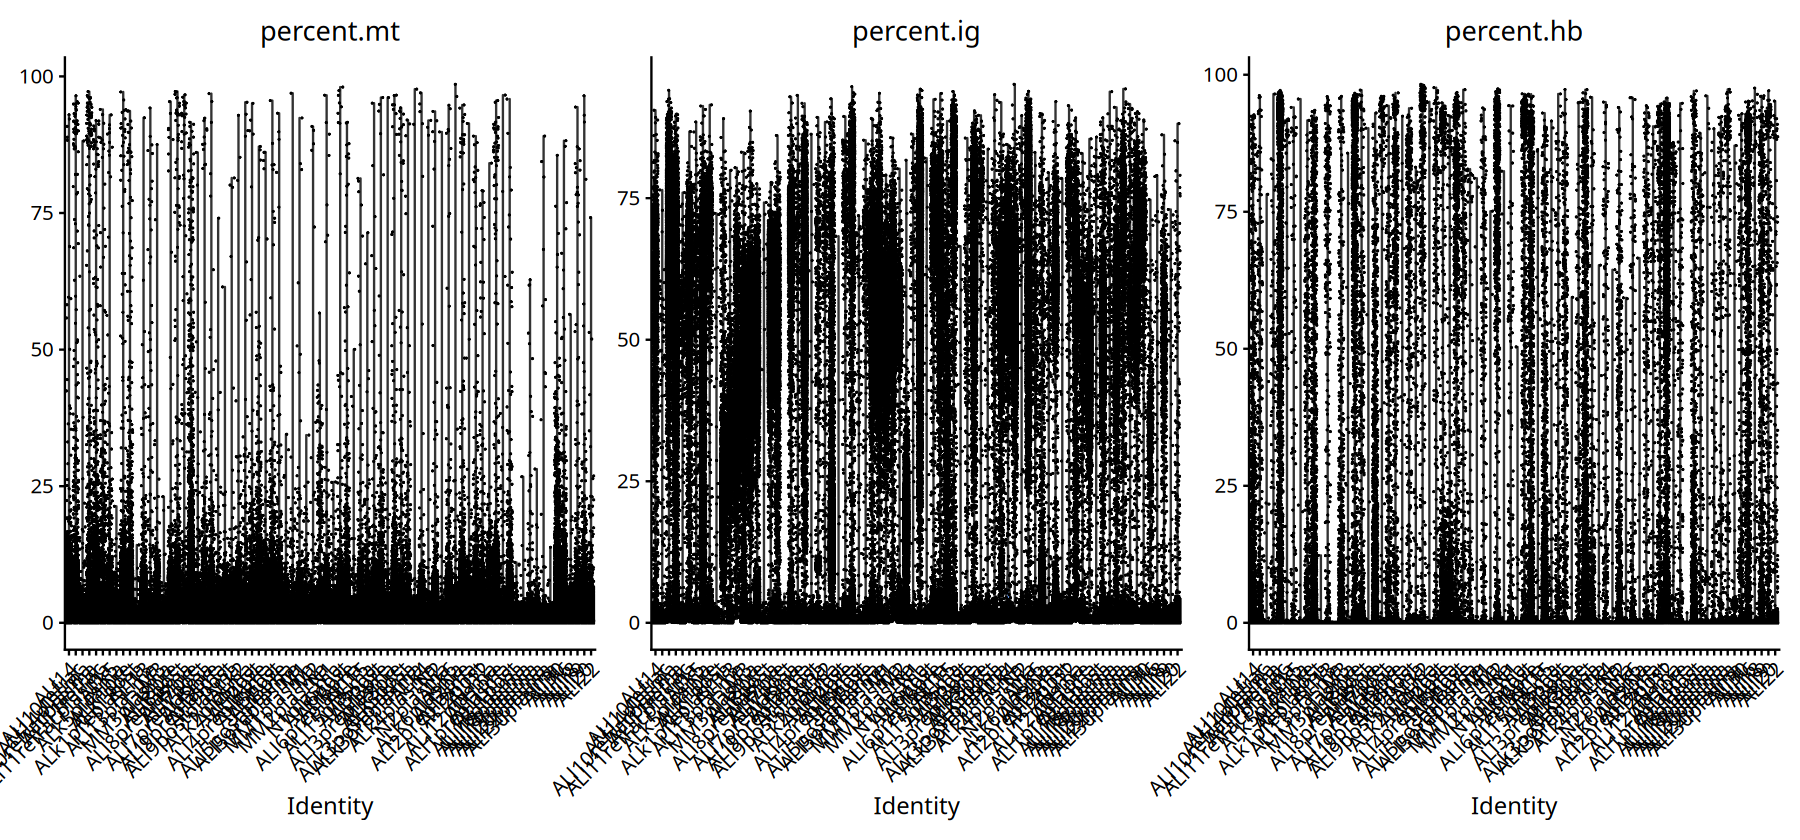

In [3]:
options(repr.plot.height=7,repr.plot.width=15)
VlnPlot(sce1, features = c("nFeature_RNA", "nCount_RNA"), ncol = 2)
VlnPlot(sce1, features = c("percent.mt","percent.ig","percent.hb"), ncol = 3)

In [4]:
sce1 <- subset(sce1, subset = nCount_RNA > 1000  & nCount_RNA < 50000  & percent.mt < 25)
sce1

An object of class Seurat 
36601 features across 692975 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



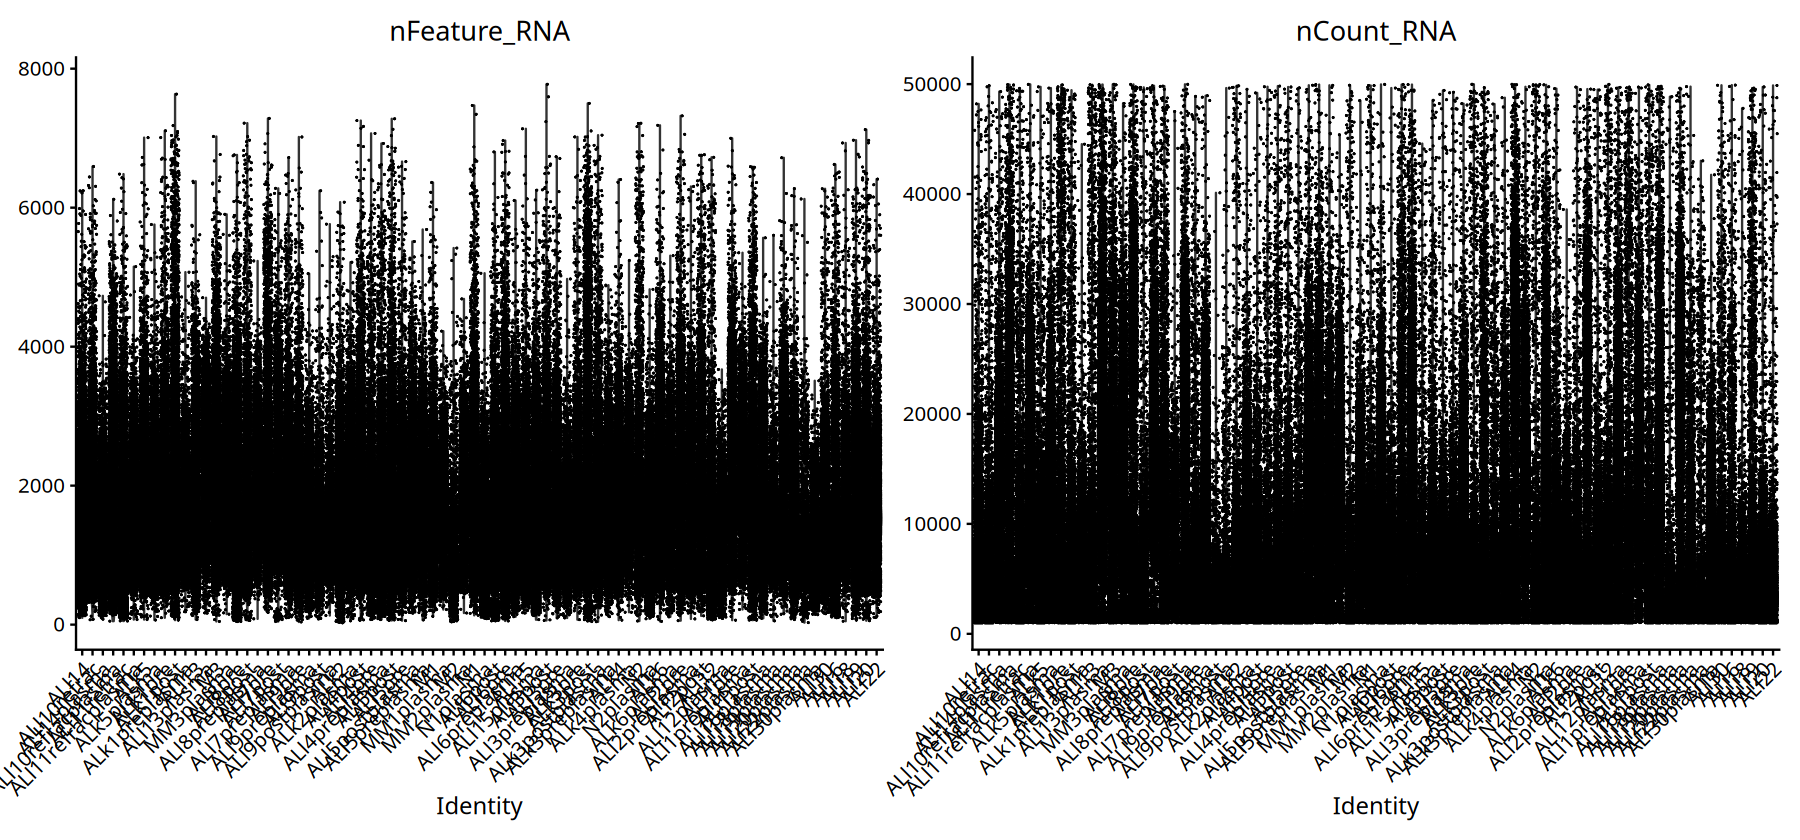

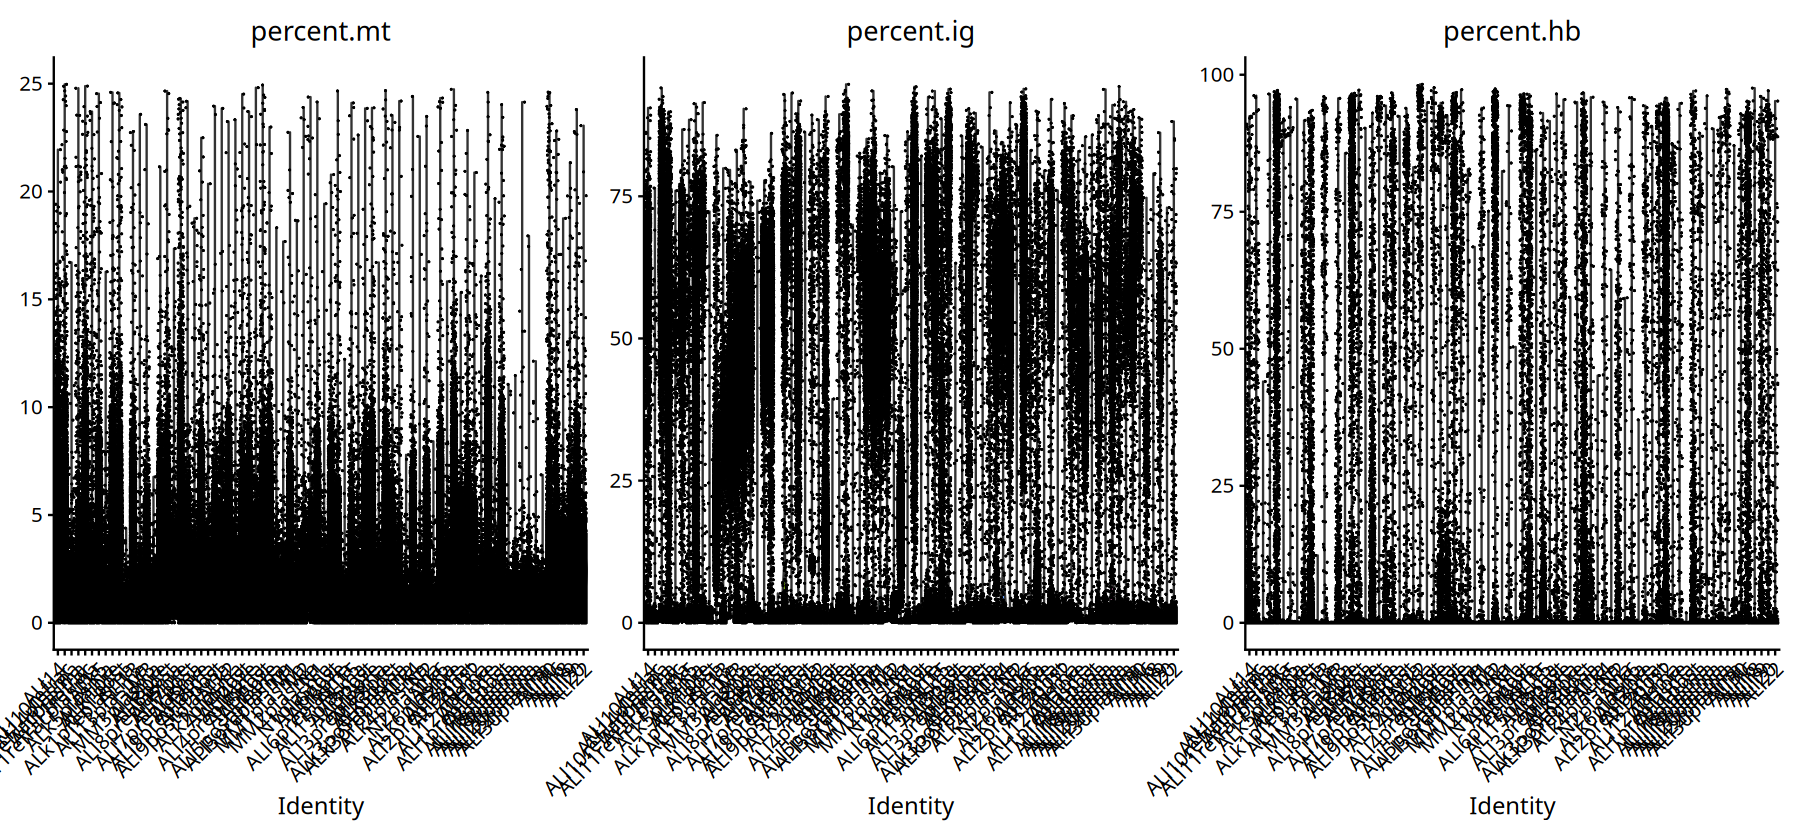

In [5]:
options(repr.plot.height=7,repr.plot.width=15)
VlnPlot(sce1, features = c("nFeature_RNA", "nCount_RNA"), ncol = 2)
VlnPlot(sce1, features = c("percent.mt","percent.ig","percent.hb"), ncol = 3)

## 2. Normalization, integration, and dimensional reduction


In [6]:
# run standard anlaysis workflow
sce1 <- NormalizeData(sce1)
sce1 <- FindVariableFeatures(sce1)
sce1 <- ScaleData(sce1)
sce1 <- RunPCA(sce1)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  CA1, AHSP, KLF1, CA2, PCLAF, NUSAP1, CENPF, HBD, RHAG, HEMGN 
	   MKI67, GYPA, BIRC5, GYPB, HBM, TOP2A, TYMS, MYL4, CDK1, ANK1 
	   DLGAP5, HMBS, CCNB2, PRC1, SLC4A1, TPX2, HIST1H1B, HBB, SPTA1, TFRC 
Negative:  TNFRSF17, RHOB, PIM2, GPRC5D, DUSP5, QPCT, PELI1, CCND1, JCHAIN, IFITM2 
	   IGHG1, JSRP1, IGKC, CDKN1A, FCRLA, ATF5, DPEP1, BMP6, PTP4A3, FAM92B 
	   RGS2, PERP, IGHG3, SLC22A17, NR4A1, SLAMF1, IGLC1, IGHG4, BCL2A1, NAMPT 
PC_ 2 
Positive:  LYZ, LST1, AIF1, FCN1, SERPINA1, FCER1G, FGL2, CEBPD, IFI30, VCAN 
	   CD14, MPEG1, FPR1, MS4A6A, CSTA, CLEC7A, DUSP6, TNFSF13B, NAMPT, SLC11A1 
	   MAFB, IGSF6, RGS2, KCTD12, C5AR1, AC020656.1, CD68, CLEC12A, CFD, LRRK2 
Negative:  TNFRSF17, PIM2, GPRC5D, PRDX2, FCRLA, IGHG1, CCND1, DUSP5, JCHAIN, DPEP1 
	   IGLC1, JSRP1, PERP, BMP6, CD79A, IGHG3, CITED2, SLAMF1, IRF4, IGLC2 
	   LMNA, IGHG4, CAV1, FAM92B, PTP4A3, ATF

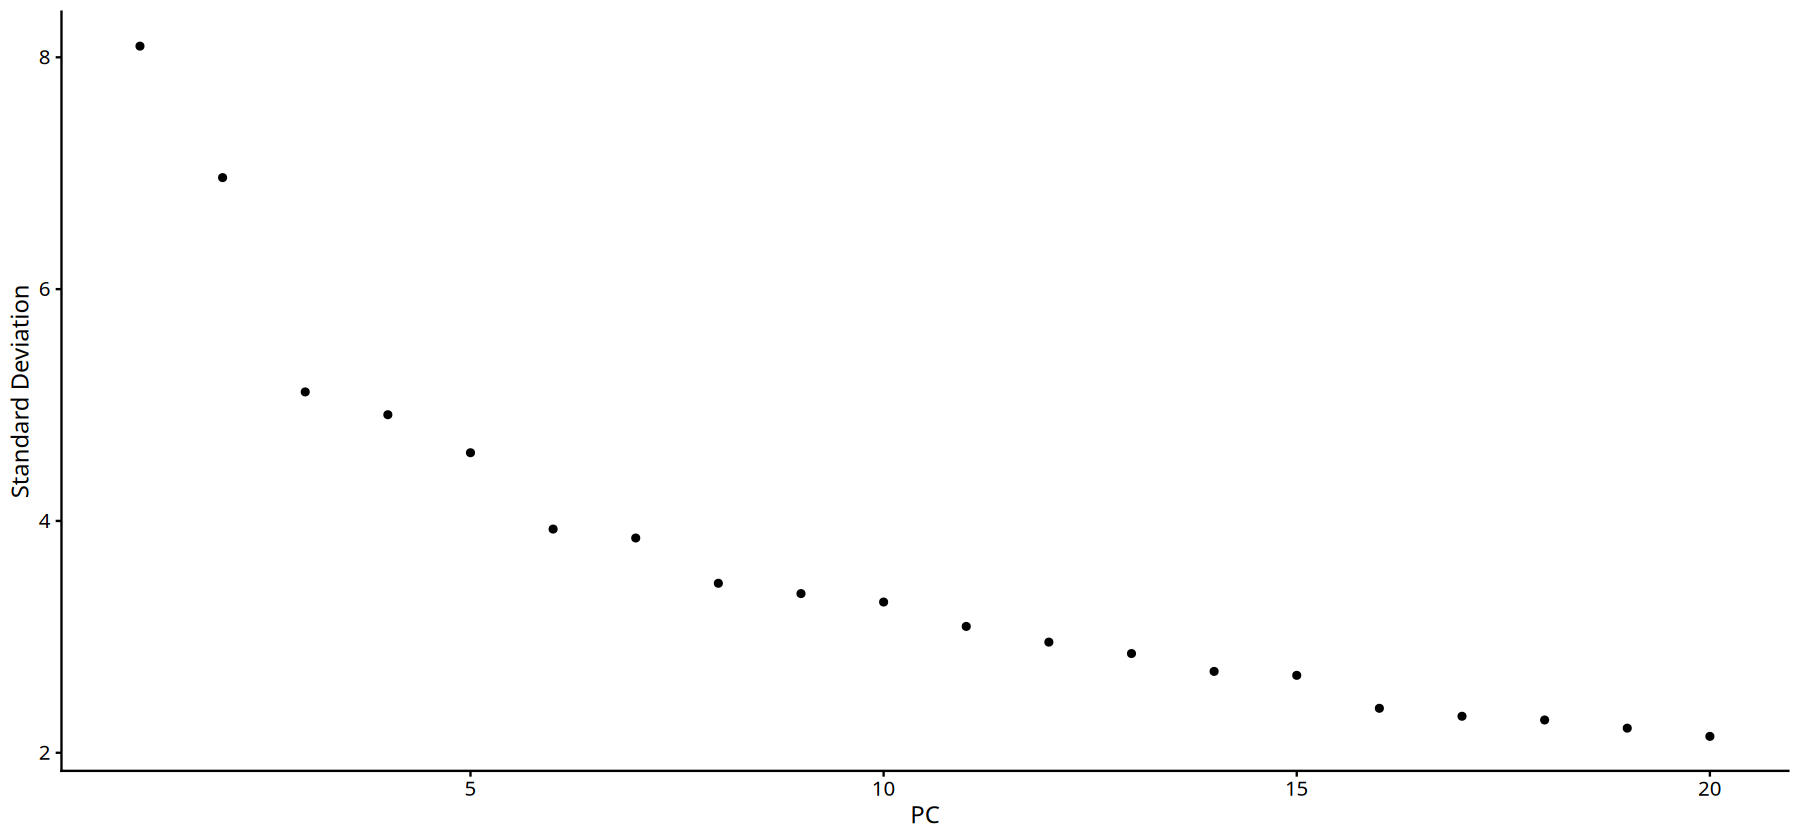

In [7]:
ElbowPlot(sce1)

Ambient RNA removal

In [8]:
#ambient RNA removal--------------------------------------------------------
# Convert Seurat object to SingleCellExperiment
sce <- sceasy::convertFormat(sce1, from="seurat", to="sce")

# Run DecontX
sce_decontX <- decontX(sce)

# Extract the decontaminated counts
decontaminated_counts <- assay(sce_decontX, "decontXcounts")

# Create a new Seurat object with decontaminated counts
sce1_clean <- CreateSeuratObject(counts = decontaminated_counts)

# Copy over the original metadata
sce1_clean@meta.data <- sce1@meta.data

sce1 <- sce1_clean

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
--------------------------------------------------

Starting DecontX

--------------------------------------------------

Fri Jul 25 01:15:45 2025 .. Analyzing all cells

Fri Jul 25 01:15:51 2025 .... Generating UMAP and estimating cell types

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 25.8 GiB”
Fri Jul 25 01:50:28 2025 .... Estimating contamination

Fri Jul 25 01:54:56 2025 ...... Completed iteration: 10 | converge: 0.05164

Fri Jul 25 01:58:54 2025 ...... Completed iteration: 20 | converge: 0.03599

Fri Jul 25 02:02:50 2025 ...... Completed iteration: 30 | converge: 0.03505

Fri Jul 25 02:06:46 2025 ...... Completed iteration: 40 | converge: 0.03899

Fri Jul 25 02

## 3. Run standard analysis workflow


In [9]:
# run standard anlaysis workflow
sce1 <- NormalizeData(sce1)
sce1 <- FindVariableFeatures(sce1)
sce1 <- ScaleData(sce1)
sce1 <- RunPCA(sce1)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  CA1, AHSP, KLF1, CA2, PCLAF, HBD, NUSAP1, RHAG, CENPF, HEMGN 
	   GYPA, MKI67, HBM, GYPB, BIRC5, TOP2A, MYL4, TYMS, ANK1, CDK1 
	   HMBS, HBB, DLGAP5, SLC4A1, CCNB2, PRC1, HIST1H1B, TPX2, TFRC, HBA1 
Negative:  TNFRSF17, RHOB, PIM2, JCHAIN, DUSP5, GPRC5D, CCND1, IGKC, IGHG1, PELI1 
	   JSRP1, FCRLA, CDKN1A, ATF5, IGHG3, DPEP1, BMP6, CD79A, PTP4A3, FAM92B 
	   PERP, IGHG4, SLC22A17, IGHA1, CAV1, IGLC1, SLAMF1, IRF4, LINC01781, ABCB9 
PC_ 2 
Positive:  TNFRSF17, PIM2, GPRC5D, PRDX2, IGHG1, JCHAIN, DUSP5, CCND1, FCRLA, IGHG3 
	   DPEP1, CD79A, JSRP1, BMP6, CITED2, PERP, IGLC1, IRF4, SLAMF1, IGLC2 
	   IGHG4, LMNA, CAV1, FAM92B, PTP4A3, IGKC, ATF5, HSPB1, UCHL1, ABCB9 
Negative:  LYZ, AIF1, LST1, FCN1, FCER1G, SERPINA1, FGL2, CEBPD, IFI30, VCAN 
	   CD14, MPEG1, MS4A6A, CSTA, FPR1, CLEC7A, DUSP6, TNFSF13B, NAMPT, SLC11A1 
	   MAFB, IGSF6, CD68, KCTD12, AC020656.1, C5A

In [10]:
sce1 <- FindNeighbors(sce1, dims = 1:15, reduction = "pca")
sce1 <- FindClusters(sce1, resolution = 1, cluster.name = "seurat_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 692975
Number of edges: 18861861

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9456
Number of communities: 60
Elapsed time: 605 seconds


In [11]:
sce1 <- RunUMAP(sce1, dims = 1:15, reduction = "pca", reduction.name = "UMAP")

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
03:07:05 UMAP embedding parameters a = 0.9922 b = 1.112

03:07:05 Read 692975 rows and found 15 numeric columns

03:07:05 Using Annoy for neighbor search, n_neighbors = 30

03:07:05 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

03:08:33 Writing NN index file to temp file /tmp/Rtmp8xO6UY/file309b06d88dbd2

03:08:33 Searching Annoy index using 1 thread, search_k = 3000

03:14:51 Annoy recall = 100%

03:14:53 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbor

Warning message:
“‘timedatectl’ indicates the non-existent timezone name ‘n/a’”
Warning message:
“Your system is mis-configured: ‘/etc/localtime’ is not a symlink”
Warning message:
“It is strongly recommended to set envionment variable TZ to ‘Etc/UCT’ (or equivalent)”
scCustomize v2.1.2
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.



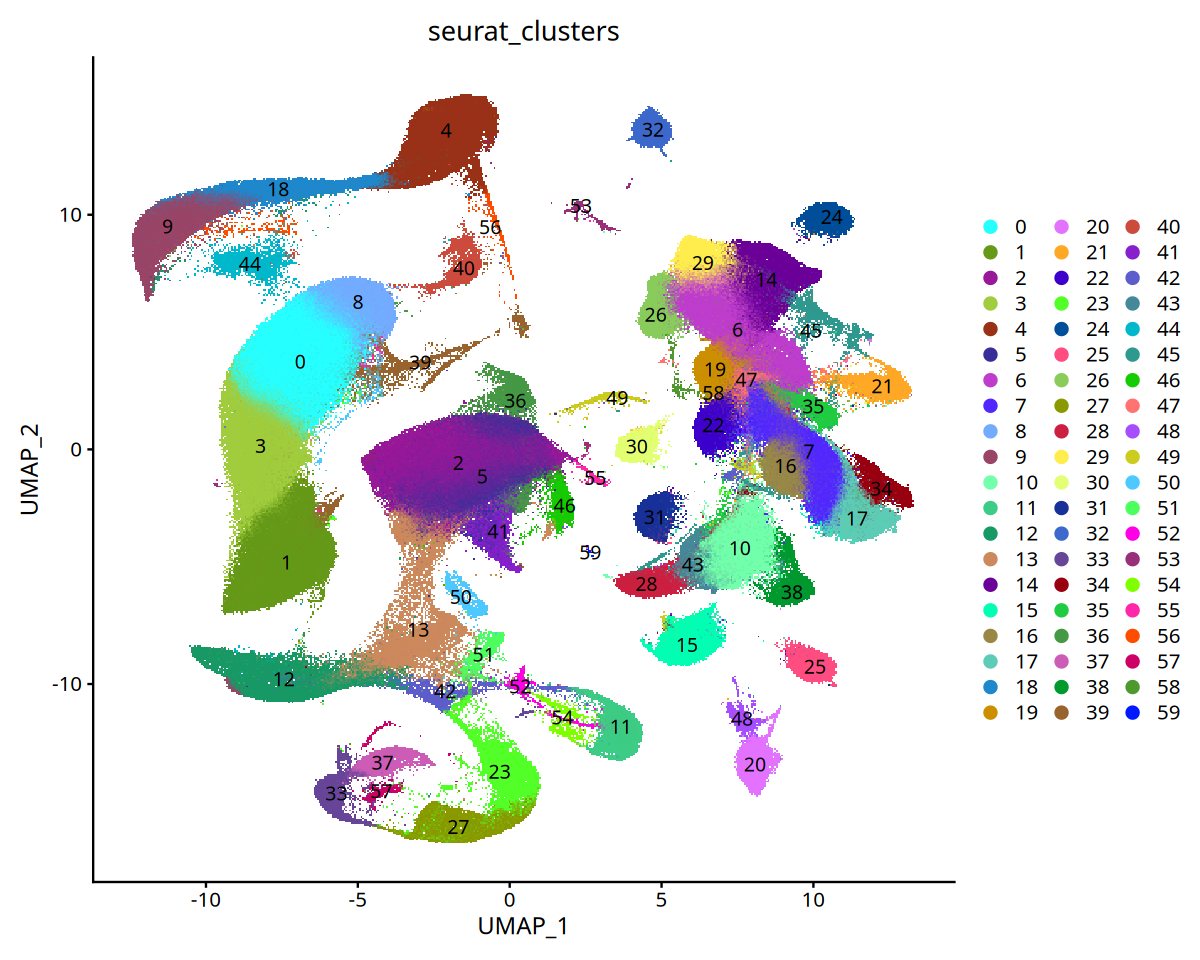

In [12]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1, pt.size=1,reduction = "UMAP", group.by = c("seurat_clusters"),label=T) 

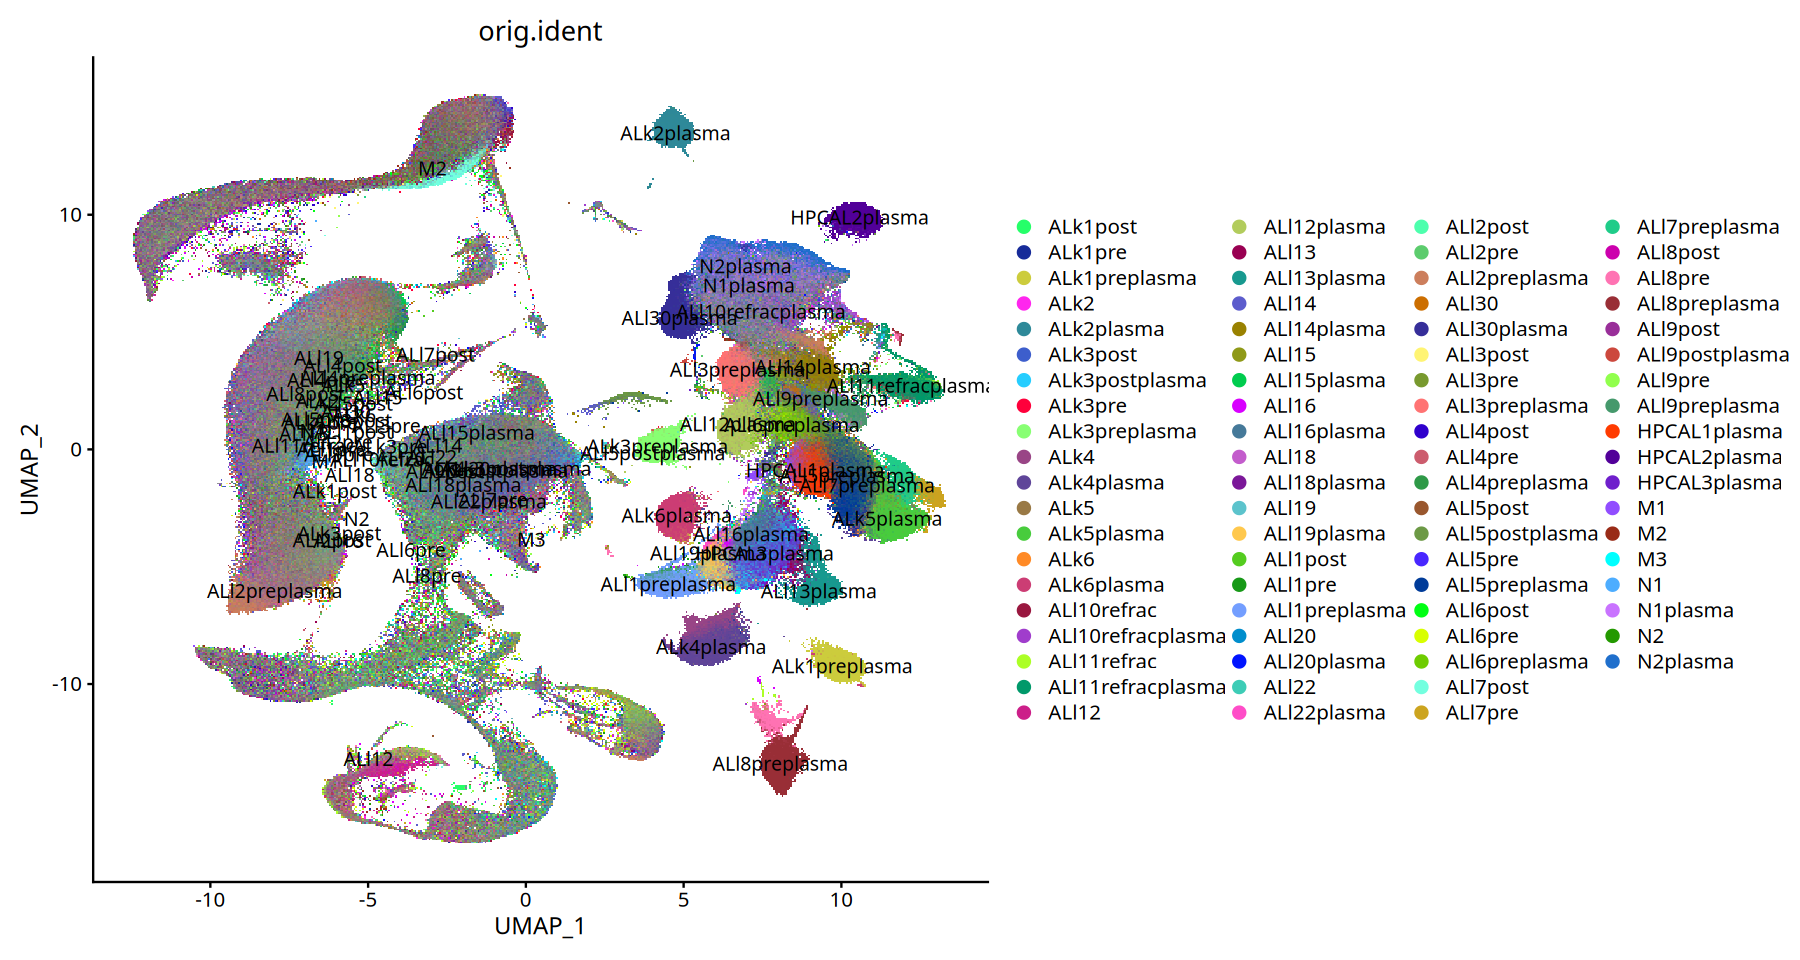

In [13]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=15)
DimPlot_scCustom(sce1, pt.size=1,reduction = "UMAP", group.by = c("orig.ident"),label=T) 

## 4. Packages and reproducibility setup


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



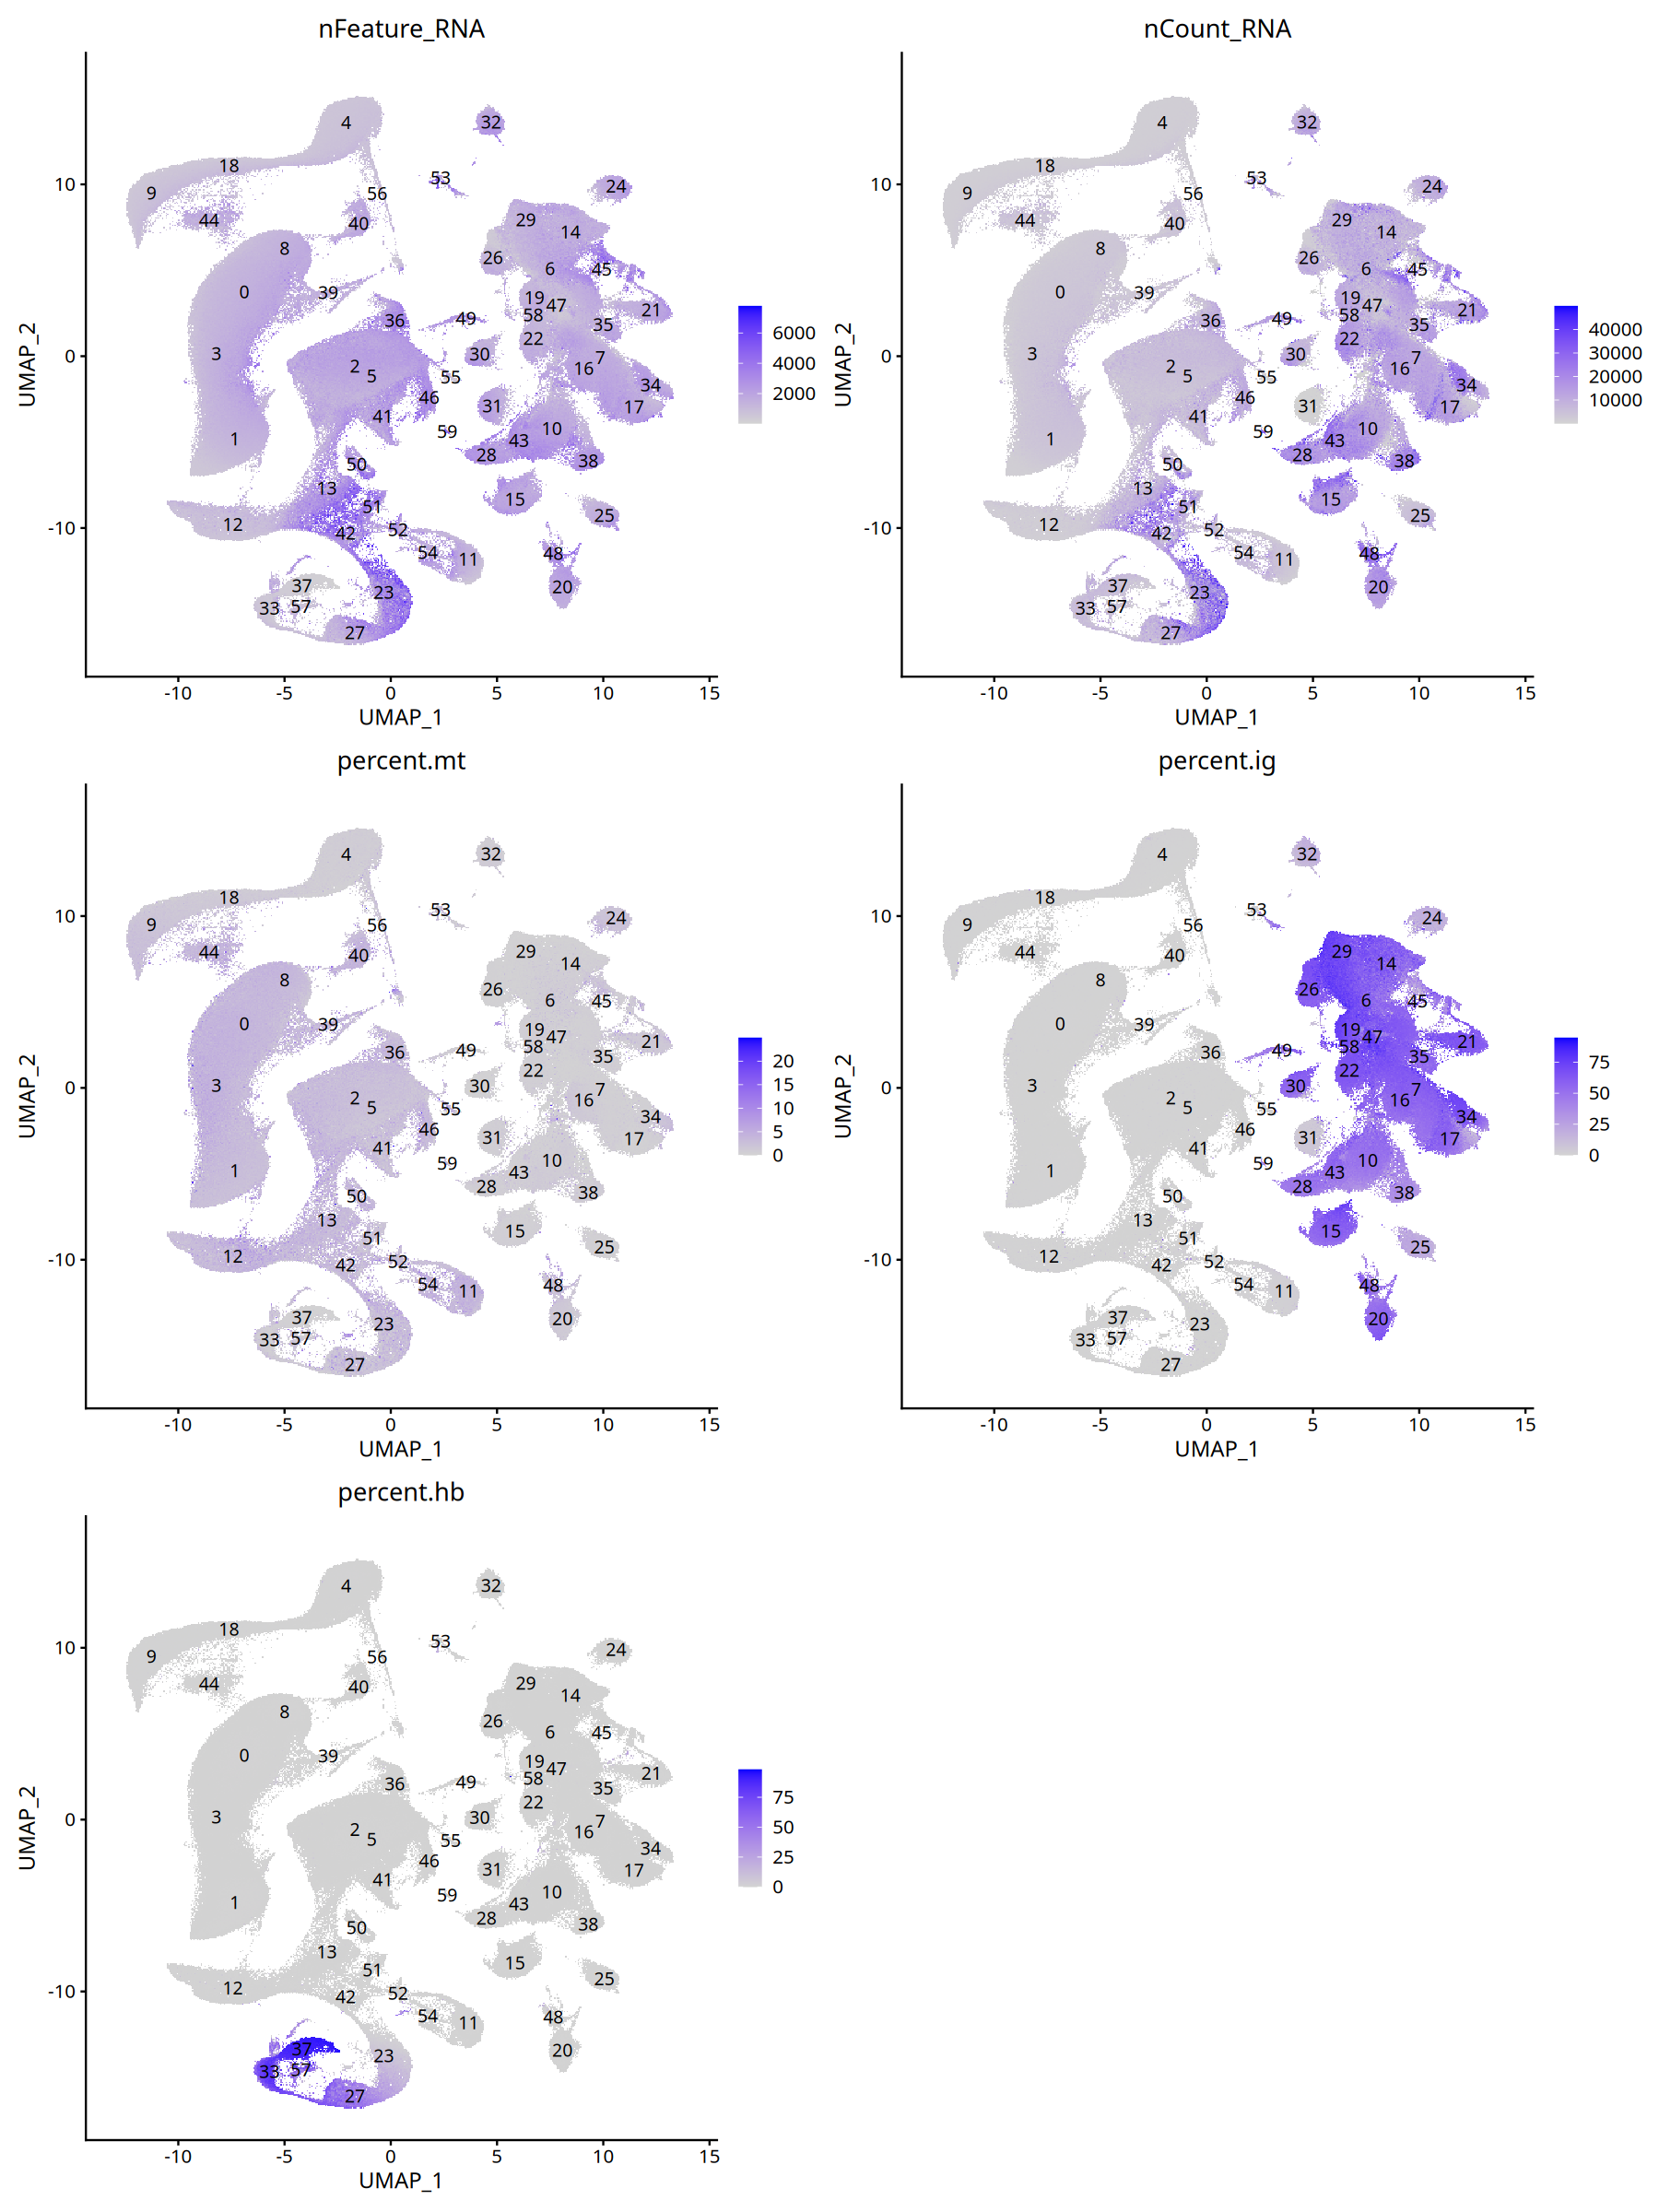

In [14]:
library('RColorBrewer')
options(repr.plot.height=20,repr.plot.width=15)
FeaturePlot(sce1, pt.size=1,reduction = "UMAP", feature = c("nFeature_RNA", "nCount_RNA","percent.mt","percent.ig","percent.hb"),label=T) 

Doublet removal

In [15]:
set.seed(123)
library(scDblFinder)
sce <- sceasy::convertFormat(sce1, from="seurat", to="sce")
library(BiocParallel)
sce_dbl <- scDblFinder(sce, samples="orig.ident",BPPARAM=MulticoreParam(1))

Warning message in .checkSCE(sce):
“Some cells in `sce` have an extremely low read counts; note that these could trigger errors and might best be filtered out”
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 stre

In [16]:
table(sce_dbl$scDblFinder.class)


singlet doublet 
 630111   62864 

## 5. Normalization, integration, and dimensional reduction


In [17]:
dbl<-data.frame(colnames(sce_dbl),sce_dbl$scDblFinder.class)
colnames(dbl)<-c('barcode','singlet')

In [18]:
sce1@meta.data<-cbind(sce1@meta.data,dbl)

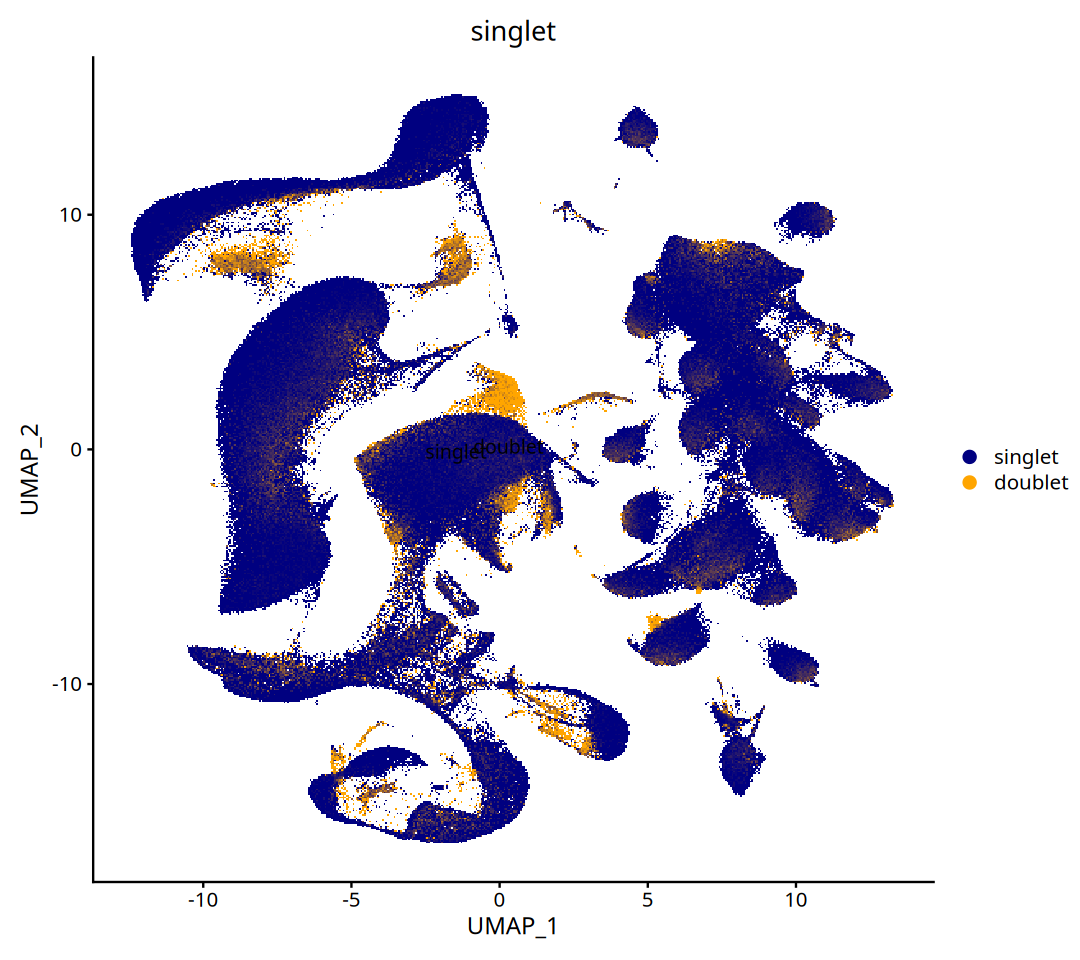

In [19]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=9)
DimPlot_scCustom(sce1, pt.size=1,reduction = "UMAP", group.by = c("singlet"),label=T,order=T) 

In [20]:
sce1 <-subset(sce1, subset = singlet == 'singlet')

In [21]:
# run standard anlaysis workflow
sce1 <- NormalizeData(sce1)
sce1 <- FindVariableFeatures(sce1)
sce1 <- ScaleData(sce1)
sce1 <- RunPCA(sce1)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
PC_ 1 
Positive:  CA1, AHSP, KLF1, CA2, PCLAF, HBD, RHAG, NUSAP1, CENPF, HEMGN 
	   GYPA, GYPB, MKI67, HBM, BIRC5, MYL4, TYMS, TOP2A, ANK1, HMBS 
	   CDK1, DLGAP5, CCNB2, HBB, PRC1, SLC4A1, HIST1H1B, TFRC, TPX2, SPTA1 
Negative:  TNFRSF17, RHOB, PIM2, JCHAIN, DUSP5, CCND1, IGKC, GPRC5D, IGHG1, IFITM2 
	   JSRP1, FCRLA, CDKN1A, IGHG3, ATF5, DPEP1, BMP6, PTP4A3, CD79A, FAM92B 
	   IGHG4, PERP, NAMPT, IGHA1, BCL2A1, FPR1, FCGR3B, LINC01781, CAV1, IGLC1 
PC_ 2 
Positive:  LYZ, LST1, AIF1, FCN1, FCER1G, SERPINA1, FGL2, IFI30, CEBPD, VCAN 
	   CD14, MPEG1, MS4A6A, CSTA, FPR1, DUSP6, CLEC7A, TNFSF13B, NAMPT, SLC11A1 
	   MAFB, AC020656.1, CD68, KCTD12, IGSF6, C5AR1, CST3, CLEC12A, CFD, S100A12 
Negative:  TNFRSF17, PIM2, GPRC5D, PRDX2, IGHG1, JCHAIN, CCND1, DUSP5, FCRLA, IGHG3 
	   CD79A, DPEP1, JSR

## 6. Normalization, integration, and dimensional reduction


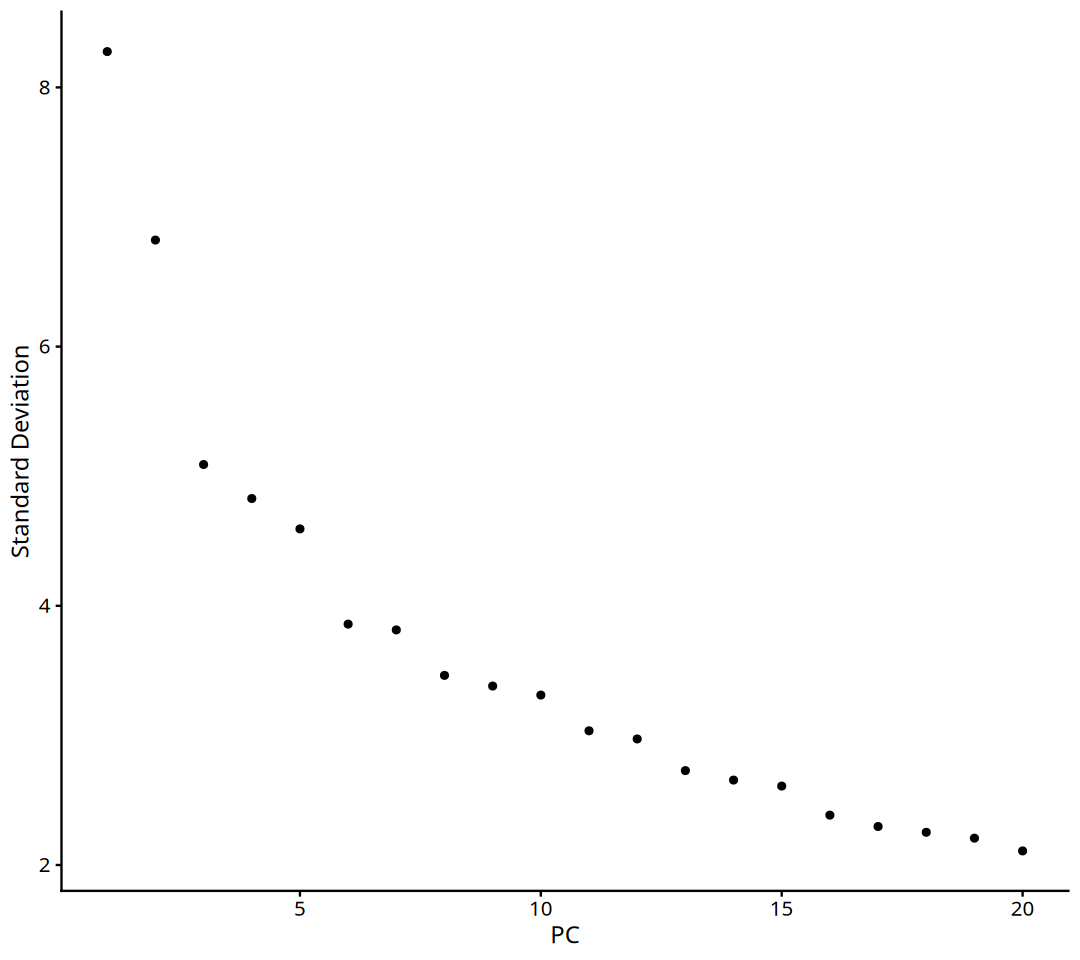

In [22]:
ElbowPlot(sce1)

In [23]:
sce1 <- FindNeighbors(sce1, dims = 1:15, reduction = "pca")
sce1 <- FindClusters(sce1, resolution = 1, cluster.name = "seurat_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 630111
Number of edges: 17048874

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9431
Number of communities: 59
Elapsed time: 547 seconds


1 singletons identified. 58 final clusters.



In [24]:
sce1 <- RunUMAP(sce1, dims = 1:15, reduction = "pca", reduction.name = "UMAP")

05:17:44 UMAP embedding parameters a = 0.9922 b = 1.112

05:17:44 Read 630111 rows and found 15 numeric columns

05:17:44 Using Annoy for neighbor search, n_neighbors = 30

05:17:44 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

05:19:01 Writing NN index file to temp file /tmp/Rtmp8xO6UY/file309b02f0e3614

05:19:01 Searching Annoy index using 1 thread, search_k = 3000

05:24:36 Annoy recall = 100%

05:24:38 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

05:25:12 Initializing from normalized Laplacian + noise (using RSpectra)

05:31:57 Commencing optimization for 200 epochs, with 28000874 positive edges

05:31:57 Using rng type: pcg

05:39:13 Optimization finished



## 7. Packages and setup


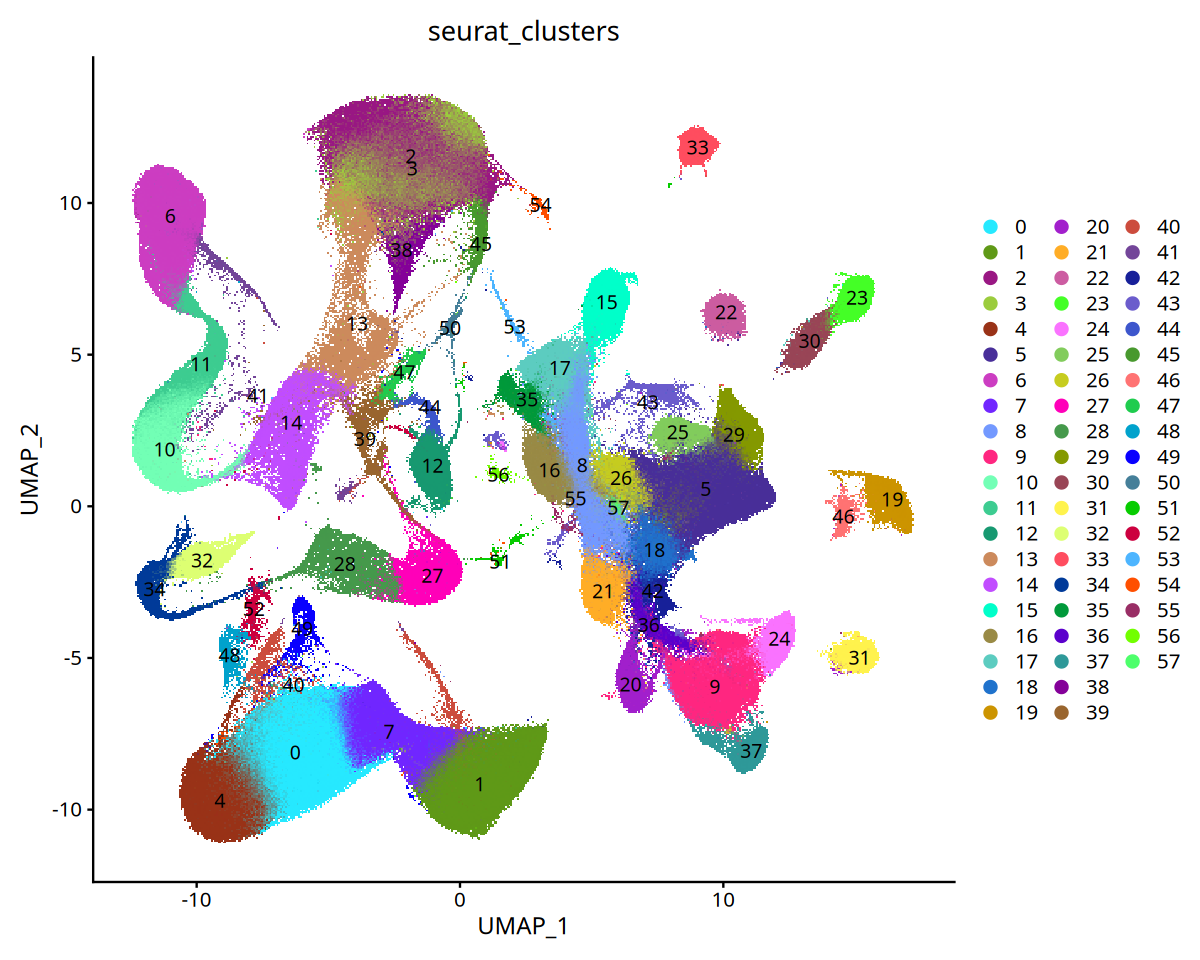

In [25]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1, pt.size=1,reduction = "UMAP", group.by = c("seurat_clusters"),label=T) 

In [28]:
sce1@meta.data$orig.ident<-gsub('M1','HPCAL1',sce1@meta.data$orig.ident)
sce1@meta.data$orig.ident<-gsub('M2','HPCAL2',sce1@meta.data$orig.ident)
sce1@meta.data$orig.ident<-gsub('M3','HPCAL3',sce1@meta.data$orig.ident)

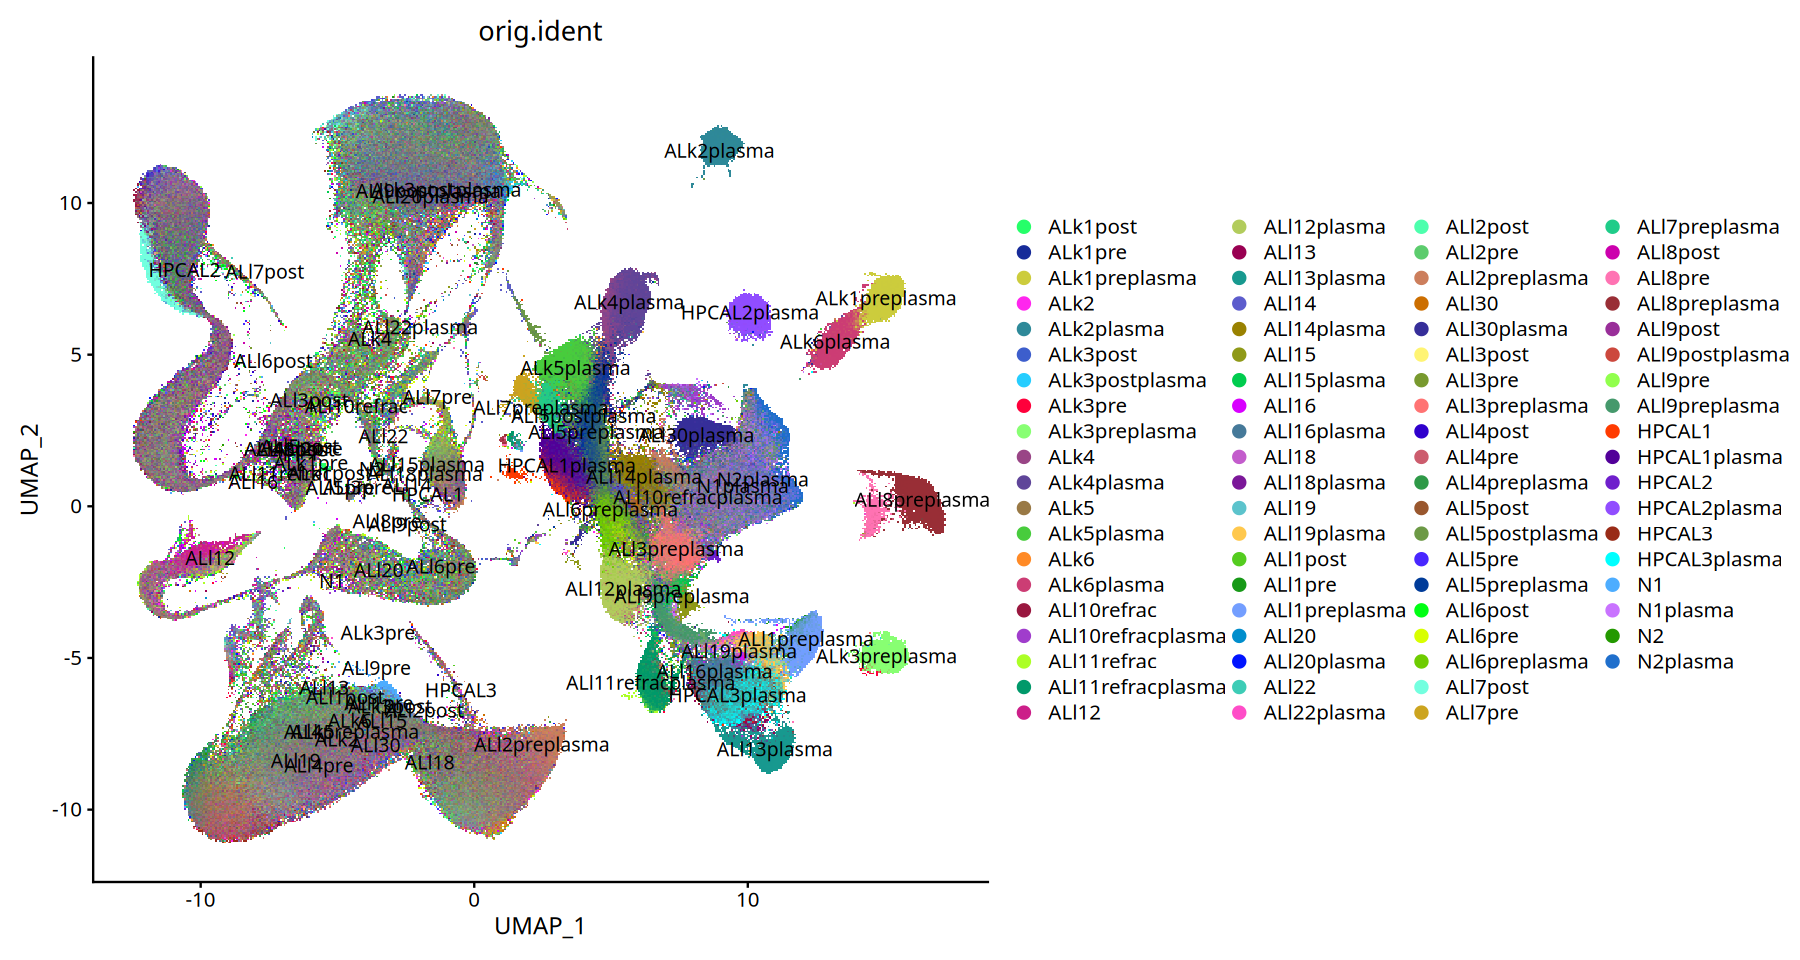

In [29]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=15)
DimPlot_scCustom(sce1, pt.size=1,reduction = "UMAP", group.by = c("orig.ident"),label=T) 

In [10]:
saveRDS(sce1,file='./250817-AL-all78umap-singletonly-umap.rds')